In [304]:
pwd

'/Users/ud4/repos/GitHub/FATESFACE/Jupyter_Notebooks'

In [305]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import socket
import glob
import numpy as np

## Logs of File
Reading the logs of the print file for the data in the file `components/elm/src/external_models/fates/biogeochem/EDPhysiologyMod.F90`

### Printing the following lines of the Phenology routine `phenology` in the file `EDPhysiologyMod.F90` for cold deciduous only

```
    print*,'sinkhole_phenology', model_day_int,temp_in_C,ncdstart,gddstart, currentSite%nchilldays, gdd_threshold,ncolddays, &
      currentSite%grow_deg_days, currentSite%cleafoffdate, currentSite%cndaysleafoff,currentSite%cleafondate,currentSite%cndaysleafon
    print*,'sinkhole_phenology_def',phen_cstat_iscold,phen_cstat_nevercold,phen_cstat_notcold

    !LEAF ON: COLD DECIDUOUS. Needs to
    !1) have exceeded the growing degree day threshold
    !2) The leaves should not be on already
    !3) There should have been at least one chilling day in the counting period.
    !   this prevents tropical or warm climate plants that are "cold-deciduous"
    !   from ever re-flushing after they have reached their maximum age (thus
    !   preventing them from competing
    print*,'sinkhole_phenology_LOn1', model_day_int,currentSite%cstatus,ED_val_phen_mindayson,currentSite%grow_deg_days,gdd_threshold,currentSite%nchilldays,currentSite%cleafondate

    if ( any(currentSite%cstatus == [phen_cstat_iscold,phen_cstat_nevercold]) .and. &
         (currentSite%grow_deg_days > gdd_threshold) .and. &
         (currentSite%cndaysleafoff > ED_val_phen_mindayson) .and. &
         (currentSite%nchilldays >= 1)) then
       currentSite%cstatus = phen_cstat_notcold  ! Set to not-cold status (leaves can come on)
       currentSite%cleafondate = model_day_int
       currentSite%cndaysleafon = 0
       currentSite%grow_deg_days = 0._r8 ! zero GDD for the rest of the year until counting season begins.
       if ( debug ) write(fates_log(),*) 'leaves on'
    endif !GDD
    print*,'sinkhole_phenology_LOn2', model_day_int,currentSite%cstatus, currentSite%cleafondate,currentSite%grow_deg_days
    
    !LEAF OFF: COLD THRESHOLD
    !Needs to:
    !1) have exceeded the number of cold days threshold
    !2) have exceeded the minimum leafon time.
    !3) The leaves should not be off already
    !4) The day of simulation should be larger than the counting period.

    print*,'sinkhole_phenology_LOff1', model_day_int,currentSite%cstatus,num_vegtemp_mem,ED_val_phen_ncolddayslim,ED_val_phen_mindayson,currentSite%cndaysleafon
    if ( (currentSite%cstatus == phen_cstat_notcold) .and. &
         (model_day_int > num_vegtemp_mem)      .and. &
         (ncolddays > ED_val_phen_ncolddayslim) .and. &
         (currentSite%cndaysleafon > ED_val_phen_mindayson) )then

       currentSite%grow_deg_days  = 0._r8          ! The equations for Botta et al
       ! are for calculations of
       ! first flush, but if we dont
       ! clear this value, it will cause
       ! leaves to flush later in the year
       currentSite%cstatus       = phen_cstat_iscold  ! alter status of site to 'leaves off'
       currentSite%cleafoffdate = model_day_int       ! record leaf off date
       currentSite%cndaysleafoff = 0

       if ( debug ) write(fates_log(),*) 'leaves off'
    endif

    print*,'sinkhole_phenology_LOff2', model_day_int,currentSite%cstatus , currentSite%grow_deg_days,currentSite%cndaysleafoff

    ! LEAF OFF: COLD LIFESPAN THRESHOLD
    ! NOTE: Some areas of the planet will never generate a cold day
    ! and thus %nchilldays will never go from zero to 1.  The following logic
    ! when coupled with this fact will essentially prevent cold-deciduous
    ! plants from re-emerging in areas without at least some cold days

    print*,'sinkhole_phenology_LOff_th', model_day_int,currentSite%cstatus, currentSite%cndaysleafoff,currentSite%cleafoffdate
    if( (currentSite%cstatus == phen_cstat_notcold)  .and. &
        (currentSite%cndaysleafoff > 400)) then   ! remove leaves after a whole year,
                                                  ! when there is no 'off' period.
       currentSite%grow_deg_days  = 0._r8

       currentSite%cstatus = phen_cstat_nevercold  ! alter status of site to imply that this
       ! site is never really cold enough
       ! for cold deciduous
       currentSite%cleafoffdate = model_day_int    ! record leaf off date
       currentSite%cndaysleafoff = 0

       if ( debug ) write(fates_log(),*) 'leaves off'
    endif
    print*,'sinkhole_phenology_LOff_th2', model_day_int,currentSite%cstatus,currentSite%grow_deg_days ,currentSite%cndaysleafoff
    
```

## More_logs: `PRTAllometricCNPMod.F90`

`885     print*, 'sinkhole_L2FR',trim(dateTimeString) ,cx_logratio, cp_ratio, cn_ratio, cx_int, &` <br>
`886         dcxdt_ratio, ema_dcxdt, cx0, l2fr_delta, l2fr, store_c_max, store_c_act, &` <br>
`887         store_nut_max, store_nut_act, l2fr_min, store_N_max, store_N_act, &     ` <br>
`888         store_P_max, store_P_act, dbh, leaf_status   `

`965          print*, 'sinkhole_Trim',trim(dateTimeString), elongf_fnrt, fnrt_flux_c, target_fnrt_c`


###  Extract selected Logs lines e.g.
`sed -n '/sinkhole/p' e3sm.log.4184005.230809-134742 > PIDH_AgBgW_r0811_l2fr.txt`

In [306]:
machine_name = socket.gethostname()
if "baseline" in machine_name:
    print("We are on: baseline")

elif "or-slurm" in machine_name:
    print ("We are on: cades")

elif "MAC132004" in machine_name:
    print("We are on: macbook")
else:
    print("other than baseline, cades, or LAB macbook")


We are on: macbook


In [307]:
# Paths
if "baseline" in machine_name:
    path_in_logs = "/ccsopen/home/ud4/repos/sharma-bharat/FATESFACE/Print_Logs/"

if "MAC132004" in machine_name:
    path_in_logs = "/Users/ud4/repos/GitHub/FATESFACE/Print_Logs"
    path_in_logs = "/Users/ud4/repos/GitHub/FATESFACE/tmp_logs/"
    path_in_logs = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240523_wL2FR_RD_processed/"
    path_in_logs = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_processed/"
    path_in_logs = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_TEST_BothLoblolly_r240529_wL2FR_RD_processed/"
    path_in_logs = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/" # RD runs

In [308]:
site = "US-DUK"
site = "US-ORN"


spins = "ad_spin"
#spins = "spin" # regular

files = glob.glob(f'{path_in_logs}/*{site}_{spins}*.txt',  
                   recursive=False) 
print(files)


['/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_allometry_fr.txt', '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_phenology_elongation.txt', '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_L2FR.txt', '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_phenology_LOff_th2.txt', '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_allometry_frEF.txt', '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_Trim.txt', '/Users/ud4/FATESMDS_analys

In [309]:
log_files = [#"Bharat_l2fr_2.txt",
             #"sinkhole_L2FR.txt", 
             #"sinkhole_Trim.txt", 
             #"sinkhole_phenology.txt",
             #"sinkhole_phenology_LOff1.txt", 
             #"sinkhole_phenology_LOff2.txt", 
             #"sinkhole_phenology_LOff_th.txt", 
             #"sinkhole_phenology_LOff_th2.txt", 
             #"sinkhole_phenology_LOn1.txt",
             #"sinkhole_phenology_LOn2.txt",
             #"sinkhole_phenology_def.txt",
             #"sinkhole_phenology_drop.txt",
             #"sinkhole_phenology_elongation.txt",
             #"sinkhole_allometry_fr.txt",
             #"sinkhole_allometry_frEF.txt",
             #"sinkhole_l2fr_pheno_Cohort1.txt",
             #"sinkhole_l2fr_pheno_Cohort2.txt",
             #"sinkhole_l2fr_FRfracdrop1.txt",
             #"sinkhole_l2fr_FRfracdrop2.txt",
             #"sinkhole_elongf_all_organs1.txt",
             #"sinkhole_elongf_all_organs2.txt",
            "sinkhole_cnplimitation_def.txt",
            ]

#### sinkhole_l2fr_pheno_Cohort1/2
prints the L2FR value of every cohort the L2FR value <br>
**Change**: get the L2FR value from cohort in this phenology subroutine <br>
Default: `l2fr               = prt_params%allom_l2fr(ipft)` <br>
`./biogeochem/EDPhysiologyMod.F90`
```
subroutine phenology_leafonoff(currentSite) 
...
print*, 'sinkhole_l2fr_pheno_Cohort1',' ', trim(dateTimeString),  l2fr
if (spinup_state == 1 .and. yr .gt. nyears_ad_carbon_only) then       
  !l2fr        = this%bc_inout(acnp_bc_inout_id_l2fr)%rval            
                                                                      
  !https://github.com/NGEET/fates/blob/f0185f7c7033fa69c80d1ddb07cbcbf1f8be1adc/biogeochem/FatesCohortMod.F90#L675
  l2fr = currentCohort%l2fr                                           
  !l2fr = currentCohort%prt%bc_inout(acnp_bc_inout_id_l2fr)%rval      
end if                                                                
print*, 'sinkhole_l2fr_pheno_Cohort2',' ' , trim(dateTimeString), l2fr
```

#### sinkhole_l2fr_FRfracdrop1/2 
prints the l2fr, target_fnrt_c, fnrt_c, eff_fnrt_drop_fraction, during shedding <br>
**No Change; printing to see the values** <br>
`./biogeochem/EDPhysiologyMod.F90`
```
print*, 'sinkhole_l2fr_FRfracdrop1',' ', trim(dateTimeString), l2fr, target_fnrt_c, fnrt_c
                                                                   
eff_leaf_drop_fraction   = max( 0.0_r8, min( 1.0_r8,1.0_r8 - target_leaf_c   / max( leaf_c  , nearzero ) ) )
eff_fnrt_drop_fraction   = max( 0.0_r8, min( 1.0_r8,1.0_r8 - target_fnrt_c   / max( fnrt_c  , nearzero ) ) )
eff_sapw_drop_fraction   = max( 0.0_r8, min( 1.0_r8,1.0_r8 - target_sapw_c   / max( sapw_c  , nearzero ) ) )
eff_struct_drop_fraction = max( 0.0_r8, min( 1.0_r8,1.0_r8 - target_struct_c / max( struct_c, nearzero ) ) )
                                                                   
print*, 'sinkhole_l2fr_FRfracdrop2',' ', trim(dateTimeString), l2fr, target_fnrt_c, fnrt_c, eff_fnrt_drop_fraction
```

#### sinkhole_elongf_all_organs1/2
prints elongf_leaf, elongf_fnrt, elongf_stem, organ_id <br>
**Change**: elongf_leaf (and others) = 1 <br>
`./parteh/PRTAllometricCNPMod.F90 `
```
if(organ_id == store_organ) then                                            
   call get_curr_time_string(dateTimeString)                                
   print*, 'sinkhole_elongf_all_organs1', ' ' , trim(dateTimeString), elongf_leaf, elongf_fnrt, elongf_stem, organ_id
   elongf_leaf = 1                                                          
   elongf_fnrt = 1                                                          
   elongf_stem = 1                                                          
   print*, 'sinkhole_elongf_all_organs2', ' ' , trim(dateTimeString), elongf_leaf, elongf_fnrt, elongf_stem, organ_id
                                                                            
   call bleaf(dbh,ipft,crown_damage,canopy_trim, elongf_leaf, leaf_c_target)
   call bfineroot(dbh,ipft,canopy_trim,l2fr, elongf_fnrt, fnrt_c_target)    
   call bsap_allom(dbh,ipft,crown_damage,canopy_trim, elongf_stem, sapw_area,sapw_c_target)
   call bagw_allom(dbh,ipft,crown_damage, elongf_stem, agw_c_target)        
   call bbgw_allom(dbh,ipft, elongf_stem, bgw_c_target)                     
   call bdead_allom(agw_c_target,bgw_c_target, sapw_c_target, ipft, struct_c_target)

```

In [310]:
files

['/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_allometry_fr.txt',
 '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_phenology_elongation.txt',
 '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_L2FR.txt',
 '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_phenology_LOff_th2.txt',
 '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_allometry_frEF.txt',
 '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-ORN_ad_spin_sinkhole_Trim.txt',
 '/Users/ud4/FATESMDS_

In [311]:
# selecting on the files that are in log_files list

selected_files = []
for file in files:
    #sinkhole_phenology_LOff1.txt
    if spins == "ad_spin":
        if ('_'.join(file.split('/')[-1].split('_')[4:]) in log_files):
            selected_files.append(file)
    elif spins == "spin":
        if ('_'.join(file.split('/')[-1].split('_')[3:]) in log_files):
            selected_files.append(file)
    else:
        if ('_'.join(file.split('/')[-1].split('_')[2:]) in log_files):
            selected_files.append(file)
    
        
    

In [290]:
selected_files

['/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_AllomBlVmaxL2FR_r240529_wL2FR_RD_processed/r240529_US-DUK_spin_sinkhole_cnplimitation_def.txt']

In [291]:
# reading the logs and saving them in dictionaries
data_logs = {}
for fname in selected_files:
    with open(f'{fname}', 'r') as infile:
        if spins == "ad_spin":
            data_logs['_'.join(fname.split('/')[-1].split('_')[4:])] = infile.read()
        elif spins == "spin":
            data_logs['_'.join(fname.split('/')[-1].split('_')[3:])] = infile.read()
        else:
            data_logs['_'.join(fname.split('/')[-1].split('_')[2:])] = infile.read()
            

In [292]:
print_key = "sinkhole_cnplimitation_def.txt"

# Split data into lines
lines = data_logs[print_key].split('\n')

# Initialize a dictionary of dataframes
dfs = {}

# Iterate over lines and create dataframes based on the first item i.e. print header
for line_idx, line in enumerate(lines[:-1]):
    parts = line.split()
    k_name = parts[0]
    if k_name not in dfs:
        dfs[k_name] = []
    dfs[k_name].append(parts[1:])
    #if line_idx>max_line_idx:
    #    break

In [293]:
column_names = {}
column_names ["sinkhole_elongf_all_organs1"] = ["Date", "elongf_leaf", "elongf_fnrt", "elongf_stem", "organ_id"]
column_names ["sinkhole_elongf_all_organs2"] = ["Date", "elongf_leaf", "elongf_fnrt", "elongf_stem", "organ_id"]
column_names ["sinkhole_l2fr_pheno_Cohort1"] = ["Date", "L2FR" ]
column_names ["sinkhole_l2fr_pheno_Cohort2"] = ["Date", "L2FR" ]
column_names ["sinkhole_l2fr_FRfracdrop1"]   = ["Date", "L2FR", "target_fnrt_c", "fnrt_c" ]
column_names ["sinkhole_l2fr_FRfracdrop2"]   = ["Date", "L2FR", "target_fnrt_c", "fnrt_c", "eff_fnrt_drop_fraction" ]
column_names ["sinkhole_allometry_fr"]       = ["Date", "bfr", "elongf_fnrt", "blmax", "l2fr", "canopy_trim" ]
column_names ["sinkhole_allometry_frEF"]     = ["Date", "bfr", "elongf_fnrt", "blmax", "l2fr", "canopy_trim" ]
column_names ["sinkhole_L2FR"]               = ["Date", 'cx_logratio', 'cp_ratio', 'cn_ratio', 'cx_int', 'dcxdt_ratio', 'ema_dcxdt', 'cx0', 
                                                'l2fr_delta', 'l2fr', 'store_c_max', 'store_c_act', 'store_nut_max', 'store_nut_act', 
                                                'l2fr_min', 'store_N_max', 'store_N_act', 'store_P_max', 'store_P_act', 'dbh', 'leaf_status']
column_names ["sinkhole_cnplimitation_def"]  = ["Date", "cnp_limiter", "daily_nh4_uptake", "daily_no3_uptake", "daily_n_gain", "daily_p_gain",
                                               "daily_p_demand", "daily_n_demand", "daily_c_efflux", "daily_n_efflux", "daily_p_efflux"]

In [294]:
# Function to replace years
def replace_year(date_str):
    # Split the date and time
    date_part, time_part = date_str.split('_')
    
    # Split the date into year, month, day
    year, month, day = date_part.split('-')
    
    # Replace the year
    if int(year) < 1500:
        year = str(int(year) + 2000)
    
    # Reassemble the date and time
    new_date_str = f"{year}-{month}-{day}"#_{time_part}"
    
    return new_date_str


In [295]:
dict_of_dataframes = {}
# Create dataframes from lists of lists
for key, values in dfs.items():
    df = pd.DataFrame(values,columns=column_names[key])
    print(f"Dataframe for {key}:")
    print(df)
    df[df.columns[1:]] = df[df.columns[1:]] .astype(float)
    dict_of_dataframes[key] = df

Dataframe for sinkhole_cnplimitation_def:
                      Date cnp_limiter         daily_nh4_uptake  \
0      0001-01-01_01:00:00           0  2.0169513692742816E-004   
1      0001-01-02_01:00:00           1  1.1689216901403538E-003   
2      0001-01-03_01:00:00           0  2.3029198939161115E-008   
3      0001-01-03_01:00:00           0  1.1642074735276503E-003   
4      0001-01-04_01:00:00           1  2.3415033450042494E-008   
...                    ...         ...                      ...   
26267  0060-12-28_01:00:00           1  5.9203039378852079E-004   
26268  0060-12-29_01:00:00           1  5.9240769829660195E-004   
26269  0060-12-30_01:00:00           2  3.0916106653568521E-009   
26270  0060-12-30_01:00:00           1  6.1077581653549756E-004   
26271  0060-12-31_01:00:00           1  6.0243450025940107E-004   

              daily_no3_uptake             daily_n_gain  \
0      5.5826753059201442E-009  2.0170071960273409E-004   
1      3.1913788416746711E-008  1.1

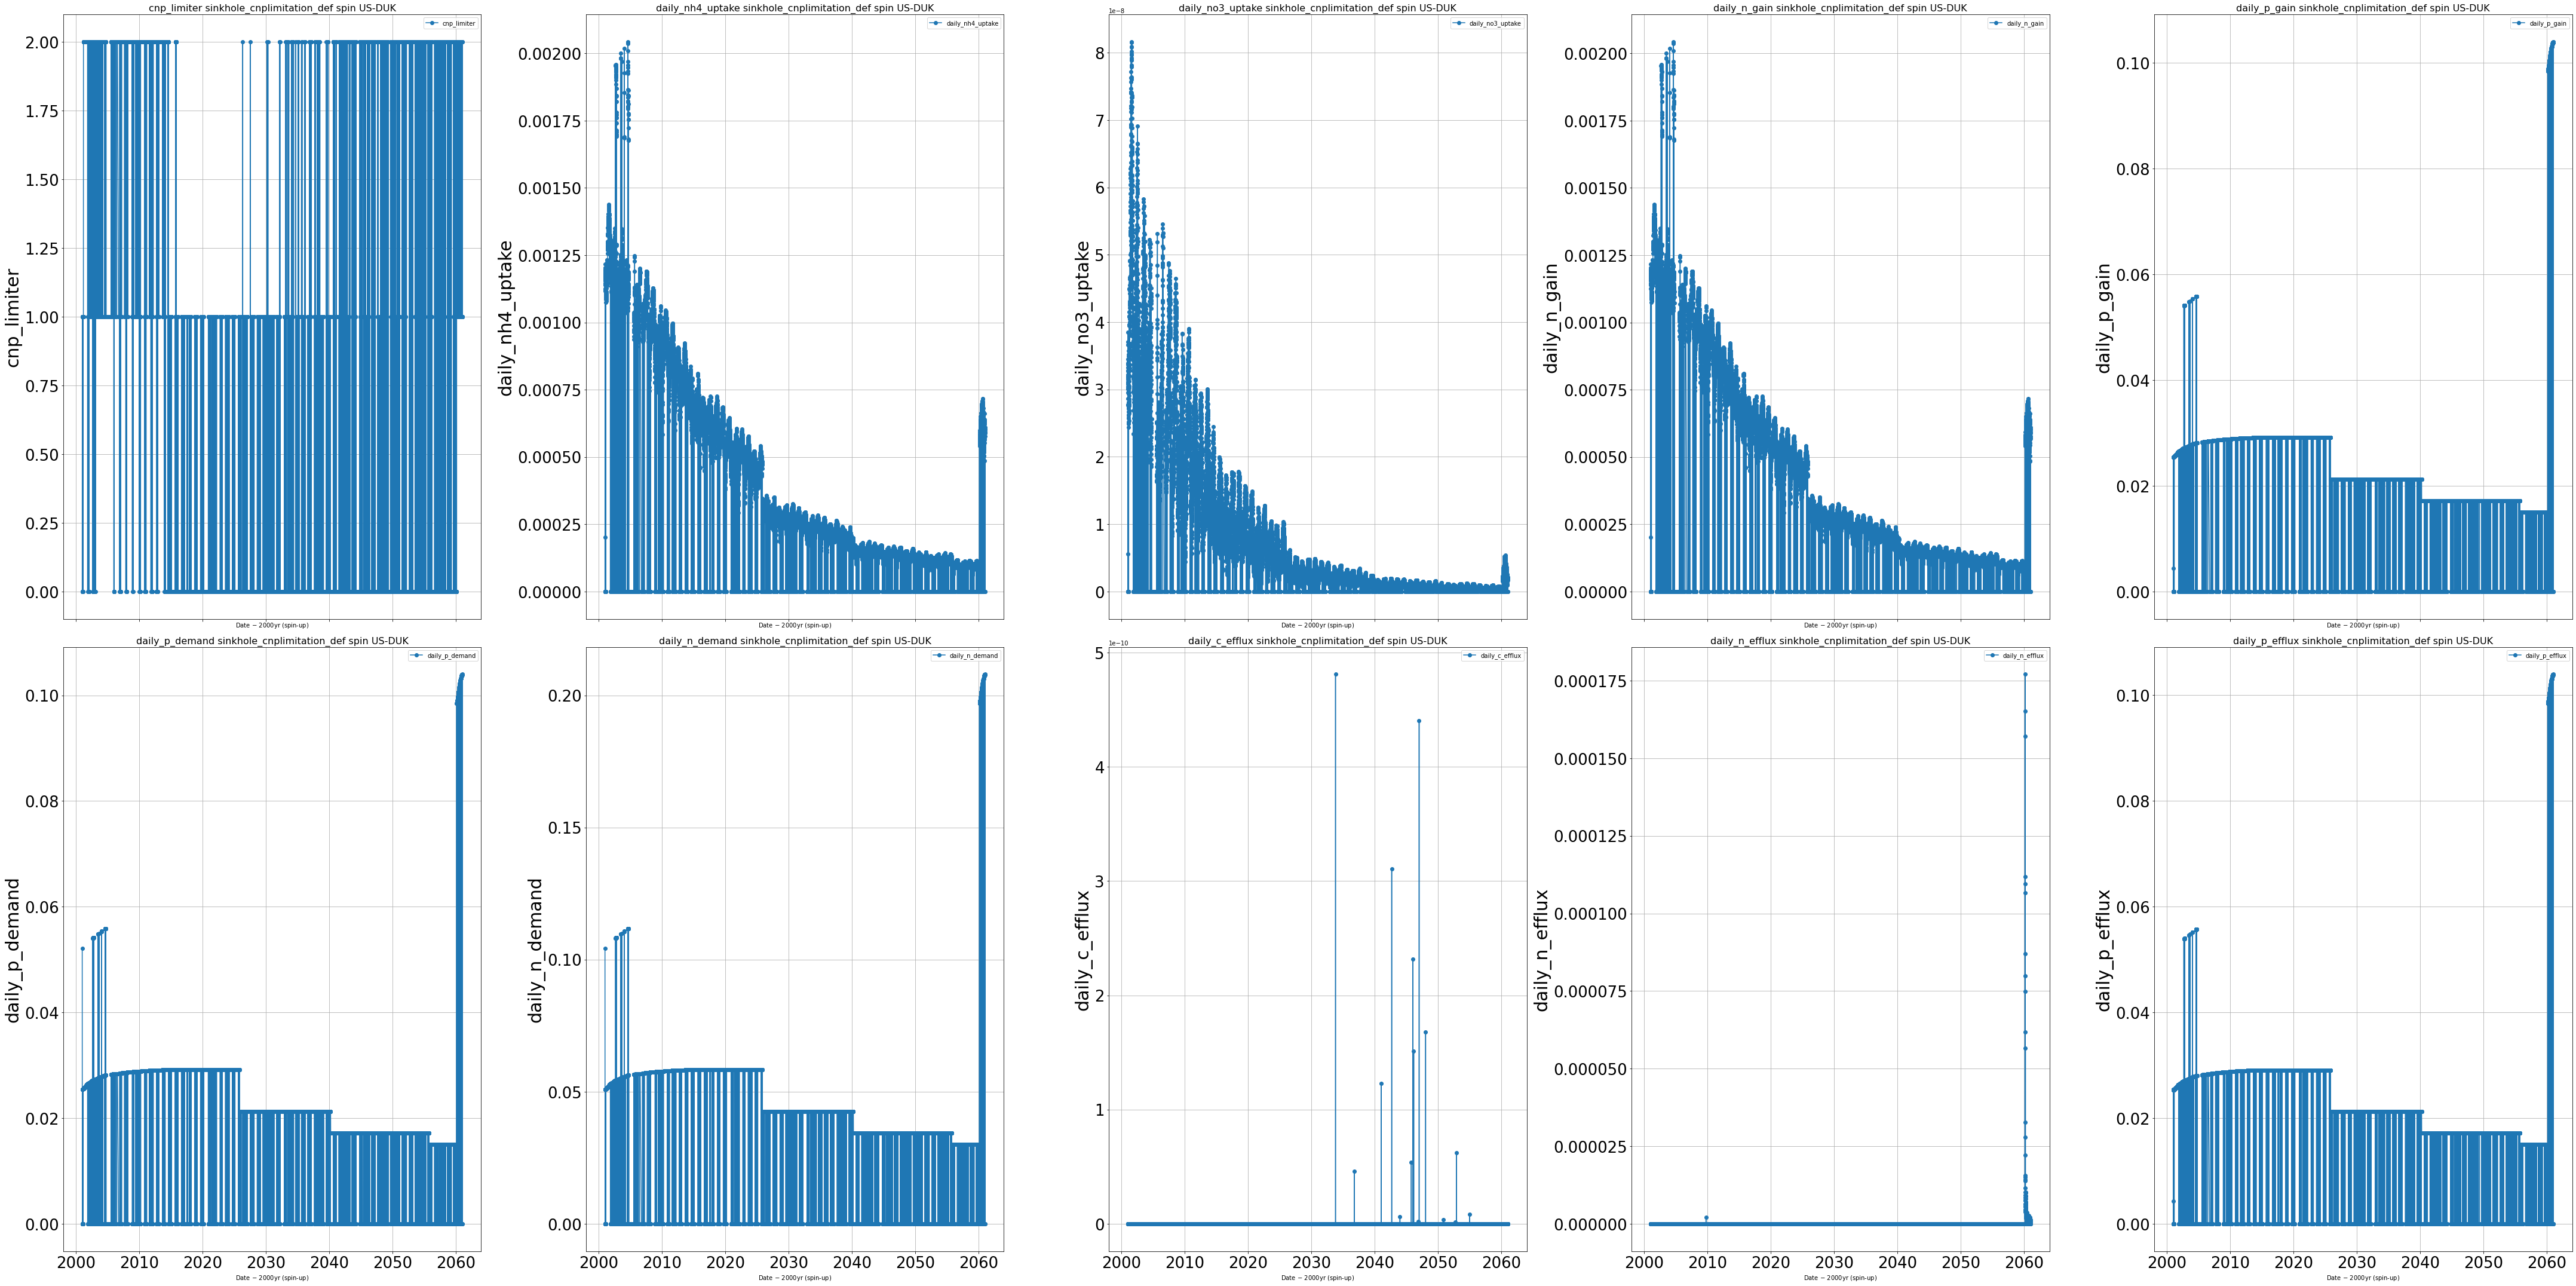

In [296]:
key = print_key.split('.')[0]
df = dict_of_dataframes[key].copy(deep=True)

# Apply the function to the Date column
df['Date'] = df['Date'].apply(replace_year)

# Convert the 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')

# Set the 'Date' column as the index
df.set_index('Date', inplace=True)

# Create subplots
num_columns = len(df.columns)


if num_columns > 6:
    max_cols = 5
    fig, axes = plt.subplots(num_columns//max_cols, max_cols, figsize=(6*num_columns, 6*max_cols), sharex=True)
else:
    fig, axes = plt.subplots(1, num_columns, figsize=(6*num_columns, 6), sharex=True)

# Plot each column in a separate subplot
for i, column in enumerate(df.columns):
    if num_columns > 6:
        x = i // max_cols
        y = i % max_cols
        axes[x,y].plot(df.index, df[column], marker='o', linestyle='-', label=column)
        axes[x,y].set_title(f'{column} {key} {spins} {site}', fontsize=16)
        axes[x,y].set_xlabel(r'Date $-$ 2000yr (spin-up)')
        axes[x,y].set_ylabel(column, fontsize=30)
        axes[x,y].legend()
        axes[x,y].grid(True)
        axes[x,y].tick_params(axis='both', which='major', labelsize=26)
    elif (num_columns > 1 ) and (num_columns < 6):
        axes[i].plot(df.index, df[column], marker='o', linestyle='-', label=column)
        axes[i].set_title(f'{column} {key} {spins} {site}', fontsize=12)
        axes[i].set_xlabel(r'Date $-$ 2000yr (spin-up)')
        axes[i].set_ylabel(column, fontsize=12)
        axes[i].legend()
        axes[i].grid(True)
    else:
        axes.plot(df.index, df[column], marker='o', linestyle='-', label=column)
        axes.set_title(f'{column} {key} {spins} {site}', fontsize=12)
        axes.set_xlabel(r'Date $-$ 2000yr (spin-up)')
        axes.set_ylabel(column, fontsize=12)
        axes.legend()
        axes.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


In [297]:
key != 'sinkhole_cnplimitation_def'

False

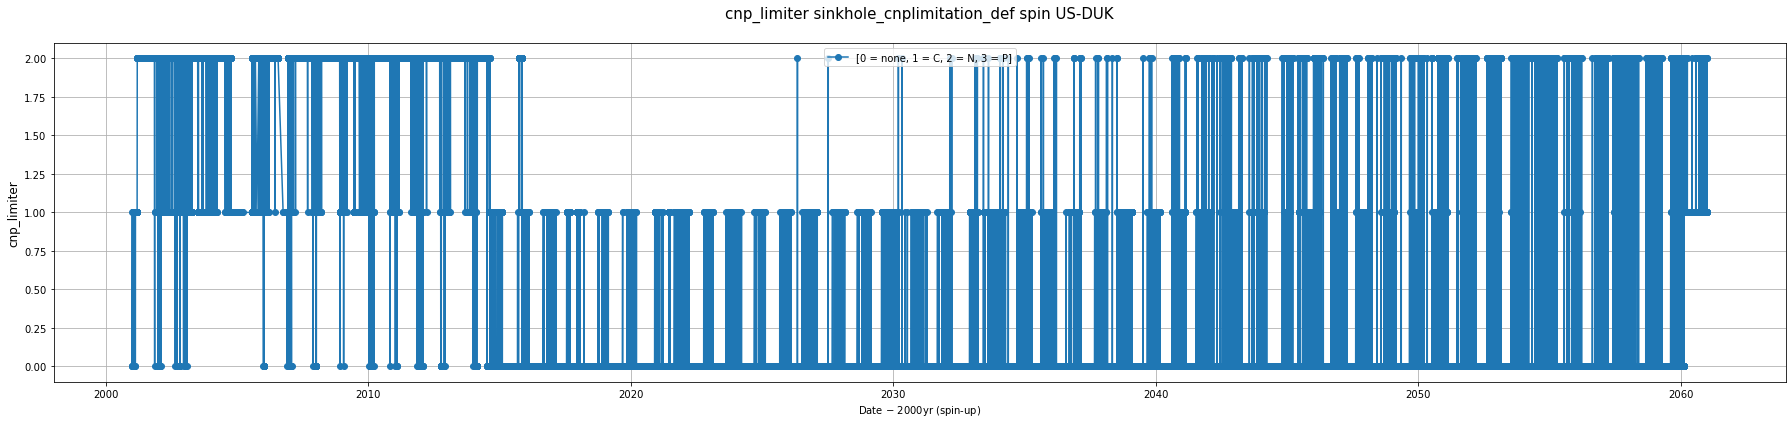

In [298]:
key = print_key.split('.')[0]
if key != 'sinkhole_cnplimitation_def':
    pritn (breakit)
df = dict_of_dataframes[key].copy(deep=True)

# Apply the function to the Date column
df['Date'] = df['Date'].apply(replace_year)

# Convert the 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')

# Set the 'Date' column as the index
df.set_index('Date', inplace=True)

df_tmp = df[["cnp_limiter"]].copy(deep=True)

# Create subplots
num_columns = len(df_tmp.columns)


if num_columns > 6:
    max_cols = 5
    fig, axes = plt.subplots(num_columns//max_cols, max_cols, figsize=(6*num_columns, 6*max_cols), sharex=True)
else:
    fig, axes = plt.subplots(1, num_columns, figsize=(25*num_columns, 6), sharex=True)

# Plot each column in a separate subplot
for i, column in enumerate(df_tmp.columns):
    if num_columns > 6:
        x = i // max_cols
        y = i % max_cols
        axes[x,y].plot(df_tmp.index, df_tmp[column], marker='o', linestyle='-', label='[0 = none, 1 = C, 2 = N, 3 = P]')
        axes[x,y].set_title(f'{column} {key} {spins} {site}\n', fontsize=16)
        axes[x,y].set_xlabel(r'Date $-$ 2000yr (spin-up)')
        axes[x,y].set_ylabel(column, fontsize=30)
        axes[x,y].legend()
        axes[x,y].grid(True)
        axes[x,y].tick_params(axis='both', which='major', labelsize=26)
    elif (num_columns > 1 ) and (num_columns < 6):
        axes[i].plot(df_tmp.index, df_tmp[column], marker='o', linestyle='-', label=column)
        axes[i].set_title(f'{column} {key} {spins} {site}\n', fontsize=12)
        axes[i].set_xlabel(r'Date $-$ 2000yr (spin-up)')
        axes[i].set_ylabel(column, fontsize=12)
        axes[i].legend()
        axes[i].grid(True)
    else:
        #single plot
        axes.plot(df_tmp.index, df_tmp[column], marker='o', linestyle='-', label='[0 = none, 1 = C, 2 = N, 3 = P]')
        axes.set_title(f'{column} {key} {spins} {site}\n', fontsize=15)
        axes.set_xlabel(r'Date $-$ 2000yr (spin-up) ')
        axes.set_ylabel(column, fontsize=12)
        axes.legend()
        axes.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


In [299]:
# Generate the complete date range
date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
# Function to exclude February 29
def exclude_feb_29(dates):
    return dates[(dates.month != 2) | (dates.day != 29)]
# Exclude February 29 from the date range and the DataFrame index
date_range = exclude_feb_29(date_range)
df_index_excluding_feb_29 = exclude_feb_29(df.index.unique())

In [300]:
# Identify missing dates
missing_dates = date_range.difference(df_index_excluding_feb_29)

In [301]:
missing_dates[300:400]

DatetimeIndex(['2006-10-14', '2006-10-15', '2006-10-16', '2006-10-17',
               '2006-10-18', '2006-10-19', '2006-10-20', '2006-10-21',
               '2006-10-22', '2006-10-23', '2006-10-24', '2006-10-25',
               '2006-10-26', '2006-10-27', '2006-10-28', '2006-10-29',
               '2006-10-30', '2006-10-31', '2006-11-01', '2006-11-02',
               '2006-11-03', '2006-11-04', '2006-11-05', '2006-11-06',
               '2006-11-07', '2006-11-08', '2006-11-09', '2006-11-10',
               '2006-11-11', '2006-11-12', '2006-11-13', '2006-11-14',
               '2006-11-15', '2006-11-16', '2006-11-17', '2006-11-18',
               '2006-11-19', '2006-11-20', '2006-11-21', '2006-11-22',
               '2006-11-23', '2006-11-24', '2025-10-24'],
              dtype='datetime64[ns]', freq=None)

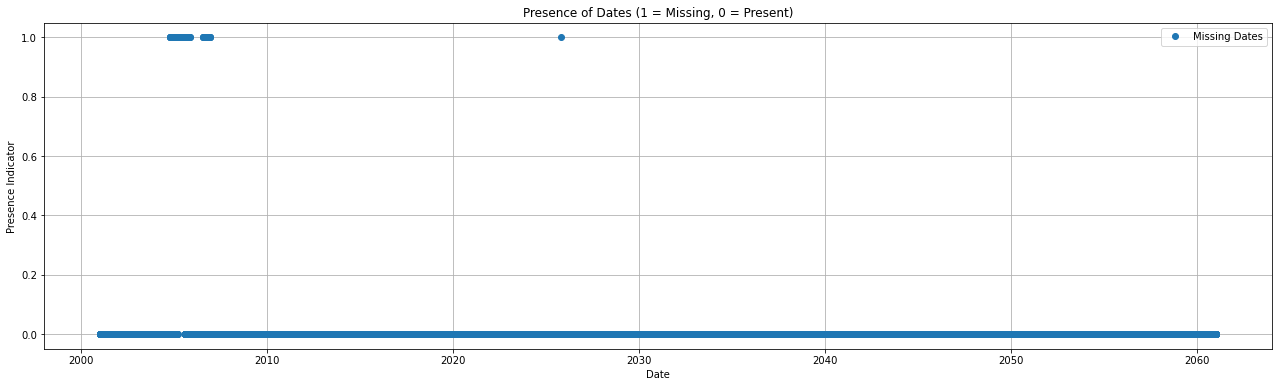

In [302]:
# Create a DataFrame to mark missing and present dates
presence_df = pd.DataFrame(index=date_range)
presence_df['Presence'] = np.where(presence_df.index.isin(df_index_excluding_feb_29), 0, 1)

# Plotting the presence of dates
plt.figure(figsize=(22, 6))
plt.plot(presence_df.index, presence_df['Presence'], 'o', label='Missing Dates')
plt.xlabel('Date')
plt.ylabel('Presence Indicator')
plt.title('Presence of Dates (1 = Missing, 0 = Present)')
plt.legend()
plt.grid(True)
plt.show()

In [303]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
df.elongf_fnrt.plot()

In [ ]:
file_name = "Phenology_log_r240313.txt"
file_name = "Phenology_log_r240313_phen500.txt"
file_name = "Logs_FR_r240512_ORNL_RD_pheno.txt"
file_name_L2FR = "Logs_FR_r240512_ORNL_RD_L2FR.txt"
file_name_trim = "Logs_FR_r240512_ORNL_RD_Trim.txt"

In [ ]:
log_files = ["Bharat_l2fr_2.txt",
             "sinkhole_L2FR.txt", 
             "sinkhole_Trim.txt", 
             "sinkhole_phenology.txt",
             "sinkhole_phenology_LOff1.txt", 
             "sinkhole_phenology_LOff2.txt", 
             "sinkhole_phenology_LOff_th.txt", 
             "sinkhole_phenology_LOff_th2.txt", 
             "sinkhole_phenology_LOn1.txt",
             "sinkhole_phenology_LOn2.txt",
             "sinkhole_phenology_def.txt",
             "sinkhole_phenology_drop.txt",
             "sinkhole_phenology_elongation.txt"
            ]

In [ ]:
log_files = ["Bharat_l2fr_2.txt",
             "sinkhole_L2FR.txt", 
             "sinkhole_Trim.txt", 
             "sinkhole_phenology.txt",
             "sinkhole_phenology_LOff1.txt", 
             "sinkhole_phenology_LOff2.txt", 
             "sinkhole_phenology_LOff_th.txt", 
             "sinkhole_phenology_LOff_th2.txt", 
             "sinkhole_phenology_LOn1.txt",
             "sinkhole_phenology_LOn2.txt",
             "sinkhole_phenology_def.txt",
             "sinkhole_phenology_drop.txt",
             "sinkhole_phenology_elongation.txt",
             "sinkhole_allometry_fr.txt",
             "sinkhole_allometry_frEF.txt"
            ]
run_id = "r240514"

In [ ]:
data_logs = {}
for lf in log_files:
    try:
        with open(f'{path_in_logs}/{run_id}_{lf}', 'r') as infile:
            data_logs[lf] = infile.read()
    except:
        pass

In [ ]:
data_logs.keys()

In [ ]:
# How long do you want the simulation plots?
max_r_years = 40
max_line_idx = max_r_years*365*8 # 30 years * 364 days * 8 freq output per day

## sinkhole_allometry_fr

In [ ]:
key = "sinkhole_allometry_fr.txt"

# Split data into lines
lines = data.split('\n')

# Initialize a dictionary of dataframes
dfs = {}

# Iterate over lines and create dataframes based on the first item i.e. print header
for line_idx, line in enumerate(lines):
    parts = line.split()
    key = parts[0]
    if key not in dfs:
        dfs[key] = []
    dfs[key].append(parts)
    if line_idx>max_line_idx:
        break



In [ ]:
# Split data into lines
lines = data.split('\n')

# Initialize a dictionary of dataframes
dfs = {}

# Iterate over lines and create dataframes based on the first item i.e. print header
for line_idx, line in enumerate(lines):
    parts = line.split()
    key = parts[0]
    if key not in dfs:
        dfs[key] = []
    dfs[key].append(parts)
    if line_idx>max_line_idx:
        break




In [ ]:
max_line_idx

In [ ]:
column_names = {}
column_names ['sinkhole_phenology'] = ['Name', 'Model_Day', 'temp_in_C', 'ncdstart','gddstart', 'nchilldays', 'gdd_threshold','ncolddays', 'grow_deg_days', 'cleafoffdate', 'cndaysleafoff','cleafondate','cndaysleafon']
column_names ['sinkhole_phenology_def'] = ['Name', 'phen_cstat_iscold', 'phen_cstat_nevercold', 'phen_cstat_notcold']
column_names ['sinkhole_phenology_LOn1'] = ['Name', 'Model_Day', 'cstatus', 'ED_val_phen_mindayson','grow_deg_days','gdd_threshold','nchilldays','cleafondate']
column_names ['sinkhole_phenology_LOn2'] = ['Name', 'Model_Day', 'cstatus', 'cleafondate','grow_deg_days']
column_names ['sinkhole_phenology_LOff1'] = ['Name', 'Model_Day', 'cstatus', 'num_vegtemp_mem','ED_val_phen_ncolddayslim','ED_val_phen_mindayson','cndaysleafon']
column_names ['sinkhole_phenology_LOff2'] = ['Name', 'Model_Day', 'cstatus', 'grow_deg_days','cndaysleafoff']
column_names ['sinkhole_phenology_LOff_th'] = ['Name', 'Model_Day', 'cstatus', 'cndaysleafoff','cleafoffdate']
column_names ['sinkhole_phenology_LOff_th2'] = ['Name', 'Model_Day', 'cstatus', 'grow_deg_days','cndaysleafoff']


In [ ]:
dict_of_dataframes = {}
# Create dataframes from lists of lists
for key, values in dfs.items():
    df = pd.DataFrame(values,columns=column_names[key])
    print(f"Dataframe for {key}:")
    print(df)
    print()
    dict_of_dataframes[key] = df

In [ ]:
# Making the columns as floats except of the 1st
for key in dict_of_dataframes.keys():
    for k in dict_of_dataframes[key].columns[1:]:
        dict_of_dataframes[key][k] = dict_of_dataframes[key][k].astype(float)

In [ ]:
dict_of_dataframes['sinkhole_phenology'].head()


In [ ]:
dict_of_dataframes['sinkhole_phenology_def'].head()


In [ ]:
dict_of_dataframes['sinkhole_phenology_LOn1'].head()


In [ ]:
dict_of_dataframes['sinkhole_phenology_LOn2'].head()


In [ ]:
dict_of_dataframes['sinkhole_phenology_LOff1'].head()


In [ ]:
dict_of_dataframes['sinkhole_phenology_LOff2'].head()


In [ ]:
dict_of_dataframes['sinkhole_phenology_LOff_th'].head()


In [ ]:
dict_of_dataframes['sinkhole_phenology_LOff_th2'].head()


In [ ]:
# Plotting
df_key = "sinkhole_phenology"
df_key_col = "temp_in_C"
plt.figure(figsize=(25,6))
plt.plot(dict_of_dataframes[f"{df_key}"].index, dict_of_dataframes[f"{df_key}"][f"{df_key_col}"], marker='o', linestyle='-')
plt.xlabel('Index')
plt.ylabel(f'{df_key_col}')
plt.title(f'{df_key_col} vs. Index')
plt.grid(True)
for i in range(max_r_years):
    plt.axvline(x = i*365, color = 'k',lw=5, alpha=.1)
    if i%5==0:
        plt.text(i*365,-10, int(i))
plt.show()



In [ ]:
# Plotting
df_key = "sinkhole_phenology"
df_key_col = "temp_in_C"

for i in range(max_r_years):
    plt.figure(figsize=(35,6))

    if i>=1:
        plt.plot(dict_of_dataframes[f"{df_key}"].index[i*365:(i+1)*365], dict_of_dataframes[f"{df_key}"][f"{df_key_col}"][i*365:(i+1)*365], marker='o', linestyle='-')
    else:
        plt.plot(dict_of_dataframes[f"{df_key}"].index[i*365:(i+1)*365], dict_of_dataframes[f"{df_key}"][f"{df_key_col}"][i*365:(i+1)*365], marker='o', linestyle='-')

    zero_indices = dict_of_dataframes[df_key][(dict_of_dataframes[df_key][df_key_col] <= 7.5) & (dict_of_dataframes[df_key].index >= i * 365) & (dict_of_dataframes[df_key].index < (i + 1) * 365)].index
    for idx in zero_indices:
        plt.axvline(x=idx, color='red', linestyle='--')



    plt.xlabel('Index')
    plt.ylabel(f'{df_key_col}')
    plt.title(f'{df_key_col} vs. Index for {i} Year')
    plt.grid(True)
#for i in range(max_r_years):
#    plt.axvline(x = i*365, color = 'k',lw=5, alpha=.1)
#    if i%5==0:
#        plt.text(i*365,-10, int(i))
#plt.show()



In [ ]:
import matplotlib.pyplot as plt

# Assuming ict_of_dataframes is a dictionary of dataframes
# Define the number of rows and columns for subplots
df_key = "sinkhole_phenology"
num_rows = len(dict_of_dataframes[f'{df_key}'].columns[1:]) # Number of rows for subplots
num_cols = 1  # Number of columns for subplots

# Create a figure and axes for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 35))

# Iterate over dataframes and plot each one on a separate subplot
for idx, df_key_col in enumerate(dict_of_dataframes[f'{df_key}'].columns[1:]):
    axes[idx].plot(dict_of_dataframes[f"{df_key}"].index, dict_of_dataframes[f"{df_key}"][f"{df_key_col}"], marker='o', linestyle='-', label=key)
    axes[idx].set_ylabel(f'{df_key_col}')
    axes[idx].set_title(f'{df_key_col} vs. Index')
    axes[idx].grid(True)
    #axes[row_idx].legend()
    axes[idx].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    for i in range(max_r_years):
        axes[idx].axvline(x = i*365, color = 'k',lw=5, alpha=.1)
        if (i%5==0) and (idx not in [2,3]):
            axes[idx].text(i*365,-10, int(i))

axes[idx].set_xlabel('Index')
# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


In [ ]:
# Ploting leafoff counter only

# Assuming ict_of_dataframes is a dictionary of dataframes
# Define the number of rows and columns for subplots

df_key = "sinkhole_phenology"
df_key_col = "cndaysleafoff"
plt.figure(figsize=(25, 7))

plt.plot(dict_of_dataframes[f"{df_key}"].index, dict_of_dataframes[f"{df_key}"][f"{df_key_col}"], marker='o', linestyle='-', label=key)
for i in range(max_r_years):
    plt.axvline(x = i*365, color = 'k',lw=5, alpha=.1)
    if max(dict_of_dataframes[f"{df_key}"][f"{df_key_col}"][i*365:(i+1)*365]) > 399.5:
        plt.axvline(x=(i+1)*365, color='red', linestyle='--')
        plt.text(i*365,400, int(max(dict_of_dataframes[f"{df_key}"][f"{df_key_col}"][i*365:(i+1)*365])),fontsize=18, color='r')
    if (i%5==0):
        plt.text((i)*365,0, int(i),fontsize=18)
plt.ylim(0,425)
plt.title(f"{df_key_col}\n", fontsize=26)
plt.grid(True)
plt.tight_layout()



#num_rows = len(dict_of_dataframes[f'{df_key}'].columns[1:]) # Number of rows for subplots
#num_cols = 1  # Number of columns for subplots

# Create a figure and axes for subplots
#fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 35))
'''
# Iterate over dataframes and plot each one on a separate subplot
for idx, df_key_col in enumerate(dict_of_dataframes[f'{df_key}'].columns[1:]):
    axes[idx].plot(dict_of_dataframes[f"{df_key}"].index, dict_of_dataframes[f"{df_key}"][f"{df_key_col}"], marker='o', linestyle='-', label=key)
    axes[idx].set_ylabel(f'{df_key_col}')
    axes[idx].set_title(f'{df_key_col} vs. Index')
    axes[idx].grid(True)
    #axes[row_idx].legend()
    axes[idx].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    for i in range(max_r_years):
        axes[idx].axvline(x = i*365, color = 'k',lw=5, alpha=.1)
        if (i%5==0) and (idx not in [2,3]):
            axes[idx].text(i*365,-10, int(i))

axes[idx].set_xlabel('Index')
# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
zero_indices = dict_of_dataframes[df_key][(dict_of_dataframes[df_key][df_key_col] <= 7.5) & (dict_of_dataframes[df_key].index >= i * 365) & (dict_of_dataframes[df_key].index < (i + 1) * 365)].index
    for idx in zero_indices:
        plt.axvline(x=idx, color='red', linestyle='--')

'''
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Assuming ict_of_dataframes is a dictionary of dataframes
# Define the number of rows and columns for subplots
df_key = "sinkhole_phenology_LOn1"
num_rows = len(dict_of_dataframes[f'{df_key}'].columns[1:]) # Number of rows for subplots
num_cols = 1  # Number of columns for subplots

# Create a figure and axes for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 35))

# Iterate over dataframes and plot each one on a separate subplot
for idx, df_key_col in enumerate(dict_of_dataframes[f'{df_key}'].columns[1:]):
    axes[idx].plot(dict_of_dataframes[f"{df_key}"].index, dict_of_dataframes[f"{df_key}"][f"{df_key_col}"], marker='o', linestyle='-', label=key)
    axes[idx].set_ylabel(f'{df_key_col}')
    axes[idx].set_title(f'{df_key_col} vs. Index')
    axes[idx].grid(True)
    #axes[row_idx].legend()
    axes[idx].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    for i in range(max_r_years):
        axes[idx].axvline(x = i*365, color = 'k',lw=5, alpha=.1)
        if (i%5==0) and (idx not in [2]):
            axes[idx].text(i*365,0, int(i))

axes[idx].set_xlabel('Index')
# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Assuming ict_of_dataframes is a dictionary of dataframes
# Define the number of rows and columns for subplots
df_key = "sinkhole_phenology_LOn2"
num_rows = len(dict_of_dataframes[f'{df_key}'].columns[1:]) # Number of rows for subplots
num_cols = 1  # Number of columns for subplots

# Create a figure and axes for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 20))

# Iterate over dataframes and plot each one on a separate subplot
for idx, df_key_col in enumerate(dict_of_dataframes[f'{df_key}'].columns[1:]):
    axes[idx].plot(dict_of_dataframes[f"{df_key}"].index, dict_of_dataframes[f"{df_key}"][f"{df_key_col}"], marker='o', linestyle='-', label=key)
    axes[idx].set_ylabel(f'{df_key_col}')
    axes[idx].set_title(f'{df_key_col} vs. Index')
    axes[idx].grid(True)
    #axes[row_idx].legend()
    axes[idx].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    for i in range(max_r_years):
        axes[idx].axvline(x = i*365, color = 'k',lw=5, alpha=.1)
        if (i%5==0) and (idx not in []):
            axes[idx].text(i*365,0, int(i))

axes[idx].set_xlabel('Index')
# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Assuming ict_of_dataframes is a dictionary of dataframes
# Define the number of rows and columns for subplots
df_key = "sinkhole_phenology_LOff1"
num_rows = len(dict_of_dataframes[f'{df_key}'].columns[1:]) # Number of rows for subplots
num_cols = 1  # Number of columns for subplots

# Create a figure and axes for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 25))

# Iterate over dataframes and plot each one on a separate subplot
for idx, df_key_col in enumerate(dict_of_dataframes[f'{df_key}'].columns[1:]):
    axes[idx].plot(dict_of_dataframes[f"{df_key}"].index, dict_of_dataframes[f"{df_key}"][f"{df_key_col}"], marker='o', linestyle='-', label=key)
    axes[idx].set_ylabel(f'{df_key_col}')
    axes[idx].set_title(f'{df_key_col} vs. Index')
    axes[idx].grid(True)
    #axes[row_idx].legend()
    axes[idx].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    for i in range(max_r_years):
        axes[idx].axvline(x = i*365, color = 'k',lw=5, alpha=.1)
        if (i%5==0) and (idx not in [2,3,4]):
            axes[idx].text(i*365,0, int(i))

axes[idx].set_xlabel('Index')
# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Assuming ict_of_dataframes is a dictionary of dataframes
# Define the number of rows and columns for subplots
df_key = "sinkhole_phenology_LOff2"
num_rows = len(dict_of_dataframes[f'{df_key}'].columns[1:]) # Number of rows for subplots
num_cols = 1  # Number of columns for subplots

# Create a figure and axes for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 20))

# Iterate over dataframes and plot each one on a separate subplot
for idx, df_key_col in enumerate(dict_of_dataframes[f'{df_key}'].columns[1:]):
    axes[idx].plot(dict_of_dataframes[f"{df_key}"].index, dict_of_dataframes[f"{df_key}"][f"{df_key_col}"], marker='o', linestyle='-', label=key)
    axes[idx].set_ylabel(f'{df_key_col}')
    axes[idx].set_title(f'{df_key_col} vs. Index')
    axes[idx].grid(True)
    #axes[row_idx].legend()
    axes[idx].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    for i in range(max_r_years):
        axes[idx].axvline(x = i*365, color = 'k',lw=5, alpha=.1)
        if (i%5==0) and (idx not in []):
            axes[idx].text(i*365,0, int(i))

axes[idx].set_xlabel('Index')
# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


In [ ]:
 import matplotlib.pyplot as plt

# Assuming ict_of_dataframes is a dictionary of dataframes
# Define the number of rows and columns for subplots
df_key = "sinkhole_phenology_LOff_th"
num_rows = len(dict_of_dataframes[f'{df_key}'].columns[1:]) # Number of rows for subplots
num_cols = 1  # Number of columns for subplots

# Create a figure and axes for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 20))

# Iterate over dataframes and plot each one on a separate subplot
for idx, df_key_col in enumerate(dict_of_dataframes[f'{df_key}'].columns[1:]):
    axes[idx].plot(dict_of_dataframes[f"{df_key}"].index, dict_of_dataframes[f"{df_key}"][f"{df_key_col}"], marker='o', linestyle='-', label=key)
    axes[idx].set_ylabel(f'{df_key_col}')
    axes[idx].set_title(f'{df_key_col} vs. Index')
    axes[idx].grid(True)
    #axes[row_idx].legend()
    axes[idx].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    for i in range(max_r_years):
        axes[idx].axvline(x = i*365, color = 'k',lw=5, alpha=.1)
        if (i%5==0) and (idx not in []):
            axes[idx].text(i*365,0, int(i))

axes[idx].set_xlabel('Index')
# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


In [ ]:
# when did the status change?

dict_of_dataframes[f"{df_key}"]["cstatus"][dict_of_dataframes[f"{df_key}"]["cstatus"]==0].head()

In [ ]:
import matplotlib.pyplot as plt

# Assuming ict_of_dataframes is a dictionary of dataframes
# Define the number of rows and columns for subplots
df_key = "sinkhole_phenology_LOff_th2"
num_rows = len(dict_of_dataframes[f'{df_key}'].columns[1:]) # Number of rows for subplots
num_cols = 1  # Number of columns for subplots

# Create a figure and axes for subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(25, 20))

# Iterate over dataframes and plot each one on a separate subplot
for idx, df_key_col in enumerate(dict_of_dataframes[f'{df_key}'].columns[1:]):
    axes[idx].plot(dict_of_dataframes[f"{df_key}"].index, dict_of_dataframes[f"{df_key}"][f"{df_key_col}"], marker='o', linestyle='-', label=key)
    axes[idx].set_ylabel(f'{df_key_col}')
    axes[idx].set_title(f'{df_key_col} vs. Index')
    axes[idx].grid(True)
    #axes[row_idx].legend()
    axes[idx].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    for i in range(max_r_years):
        axes[idx].axvline(x = i*365, color = 'k',lw=5, alpha=.1)
        if (i%5==0) and (idx not in []):
            axes[idx].text(i*365,0, int(i))

axes[idx].set_xlabel('Index')
# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


## Mystery

What happend a day before that led to state change?


In [ ]:
index = 7290
print(f"index:{index}")
print(f"cstatus: {dict_of_dataframes[f'sinkhole_phenology_LOff_th']['cstatus'][index]}")
print ("That means the state is 'phen_cstat_notcold' state and leaves are allowed to flush")
print(f"grow_deg_days: {dict_of_dataframes[f'sinkhole_phenology_LOn1']['grow_deg_days'][index]}")
print(f"gdd_threshold: {round(dict_of_dataframes[f'sinkhole_phenology_LOn1']['gdd_threshold'][index],3)}")
print(f"cleafondate: {dict_of_dataframes[f'sinkhole_phenology_LOn1']['cleafondate'][index]}")
print(f"nchilldays: {dict_of_dataframes[f'sinkhole_phenology_LOn1']['nchilldays'][index]}")
print(f"cndaysleafon: {dict_of_dataframes[f'sinkhole_phenology_LOff1']['cndaysleafon'][index]}")
print(f"temp_in_C: {round(dict_of_dataframes[f'sinkhole_phenology']['temp_in_C'][index],3)}")
print(f"ncdstart: {round(dict_of_dataframes[f'sinkhole_phenology']['ncdstart'][index],3)}")
print (f"Nov 1 after 19 years {365*19+270}")
print(f"gddstart: {round(dict_of_dataframes[f'sinkhole_phenology']['gddstart'][index],3)}")
print (f"Jan 1 after 19 years {365*19+1}")
print (f"Jan 1 after 20 years {365*20+1}")
print(f"ncolddays: {round(dict_of_dataframes[f'sinkhole_phenology']['ncolddays'][index],3)}")
print(f"cleafoffdate: {round(dict_of_dataframes[f'sinkhole_phenology']['cleafoffdate'][index],3)}")
print(f"cndaysleafoff: {round(dict_of_dataframes[f'sinkhole_phenology']['cndaysleafoff'][index],3)}")
print(f"cleafondate: {round(dict_of_dataframes[f'sinkhole_phenology']['cleafondate'][index],3)}")
print(f"cndaysleafon: {round(dict_of_dataframes[f'sinkhole_phenology']['cndaysleafon'][index],3)}")





In [ ]:
index = 7294
print(f"index:{index}")
print(f"cstatus: {dict_of_dataframes[f'sinkhole_phenology_LOff_th']['cstatus'][index]}")
print ("That means the state is 'phen_cstat_notcold' state and leaves are allowed to flush")
print(f"grow_deg_days: {dict_of_dataframes[f'sinkhole_phenology_LOn1']['grow_deg_days'][index]}")
print(f"gdd_threshold: {round(dict_of_dataframes[f'sinkhole_phenology_LOn1']['gdd_threshold'][index],3)}")
print(f"cleafondate: {dict_of_dataframes[f'sinkhole_phenology_LOn1']['cleafondate'][index]}")
print(f"nchilldays: {dict_of_dataframes[f'sinkhole_phenology_LOn1']['nchilldays'][index]}")
print(f"cndaysleafon: {dict_of_dataframes[f'sinkhole_phenology_LOff1']['cndaysleafon'][index]}")
print(f"temp_in_C: {round(dict_of_dataframes[f'sinkhole_phenology']['temp_in_C'][index],3)}")
print(f"ncdstart: {round(dict_of_dataframes[f'sinkhole_phenology']['ncdstart'][index],3)}")
print (f"Nov 1 after 19 years {365*19+270}")
print(f"gddstart: {round(dict_of_dataframes[f'sinkhole_phenology']['gddstart'][index],3)}")
print (f"Jan 1 after 19 years {365*19+1}")
print (f"Jan 1 after 20 years {365*20+1}")
print(f"ncolddays: {round(dict_of_dataframes[f'sinkhole_phenology']['ncolddays'][index],3)}")
print(f"cleafoffdate: {round(dict_of_dataframes[f'sinkhole_phenology']['cleafoffdate'][index],3)}")
print(f"cndaysleafoff: {round(dict_of_dataframes[f'sinkhole_phenology']['cndaysleafoff'][index],3)}")
print(f"cleafondate: {round(dict_of_dataframes[f'sinkhole_phenology']['cleafondate'][index],3)}")
print(f"cndaysleafon: {round(dict_of_dataframes[f'sinkhole_phenology']['cndaysleafon'][index],3)}")





## Logs Trim

In [ ]:
# Split data into lines
lines = data_trim.split('\n')
data = lines[:-1]

data_split = [s.split() for s in data]
dates = [s[0].split('sinkhole_Trim')[-1] for s in data_split]
values = [s[1:] for s in data_split]
# Create DataFrame
df_trim = pd.DataFrame(values, columns=['elongf_fnrt', 'fnrt_flux_c', 'target_fnrt_c'])
# Add Date column
df_trim = df_trim.astype('float64')
dates_new = [d.split('_')[0] for d in dates]
# Replace '00' with '20'
new_date_str  = [d.replace('00', '20') for d in dates_new]
df_trim['Date'] = new_date_str
df_trim['Date'] = pd.to_datetime(df_trim['Date'], format='%Y-%m-%d')

In [ ]:
vars = ("FATES_SAPWOODC",
        "FATES_FROOTC"
       )


for idx, key in enumerate(ds.keys()):
    plt.figure(figsize=(20,6))
    for var in vars:
        try:
            
            plt.plot(ds[key][var], label = var)
            plt.title(f"{ds[key][var].long_name} ({var}) - {key} - AnnualSUM | Units: {ds[key][var].units}")
            #plt.axvline(x = 1982, color = 'r',lw=5, label = 'logging year', alpha=.2)
            plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
            #plt.axvline(x = 1996, color = 'g',lw=5, label = 'logging year', alpha=.2)
            #plt.xlim(1850,2010)
            #plt.ylim(0,1.1)
            if idx != len(ds.keys())-1 : 
                plt.xticks([])
                plt.xlabel(None)
            print (ds[key][var].long_name )
            plt.legend()
            plt.xlim(0,max_r_years*365)
            for i in range(max_r_years):
                plt.axvline(x = i*365, color = 'k',lw=5, alpha=.02)
                if i%5==0:
                    plt.text(i*365,0, int(i))
        except:
            continue
        
# Remarks: 

In [ ]:
plt.figure(figsize=(20,6))
plt.plot (df_trim ['Date'], df_trim [ 'fnrt_flux_c'], 'r*')
plt.ylabel ('fnrt_flux_c')
plt.show()
plt.figure(figsize=(20,6))
plt.plot (df_trim ['Date'], df_trim [ 'target_fnrt_c'], 'k+')
plt.ylabel ('target_fnrt_c')
plt.show()
plt.figure(figsize=(20,6))
plt.plot (df_trim ['Date'], df_trim [ 'fnrt_flux_c']/df_trim [ 'target_fnrt_c'], 'k+')
plt.ylabel ('fnrt_flux_c/target_fnrt_c')
plt.show()

### Logs L2FR

In [ ]:
### Logs L2FR
columns_names = ['cx_logratio', 'cp_ratio', 'cn_ratio',
'cx_int', 'dcxdt_ratio', 'ema_dcxdt', 'cx0', 'l2fr_delta', 'l2fr', 'store_c_max', 'store_c_act',
'store_nut_max', 'store_nut_act', 'l2fr_min', 'store_N_max', 'store_N_act',
'store_P_max', 'store_P_act', 'dbh', 'leaf_status']
len(columns_names)

In [ ]:
# Split data into lines
lines = data_L2FR.split('\n')
data = lines[:-1]

data_split = [s.split() for s in data]
dates = [s[0].split('sinkhole_L2FR')[-1] for s in data_split]
values = [s[1:] for s in data_split]
# Create DataFrame
df_l2fr = pd.DataFrame(values, columns=columns_names)
# Add Date column
df_l2fr = df_l2fr.astype('float64')
df_l2fr['Date'] = dates
dates_new = [d.split('_')[0] for d in dates]
# Replace '00' with '20'
new_date_str  = [d.replace('00', '20') for d in dates_new]
df_l2fr['Date'] = new_date_str
df_l2fr['Date'] = pd.to_datetime(df_l2fr['Date'], format='%Y-%m-%d')

In [ ]:
# Notes:
# L2FR only runs when leafstatus =2

In [ ]:
df_l2fr

In [ ]:

plt.figure(figsize=(20,6))
plt.plot (df_l2fr ['Date'], df_l2fr [ 'store_nut_act'], 'r*')
plt.ylabel ('store_nut_act')
plt.show()